# 07 — ISPNet (RevIN-GRU): Dataset-Tailored Forecasting Model

Proposed model for CESNET-TimeSeries24. RevIN applied to GRU backbone, motivated by EDA.

| EDA Finding | ISPNet Design Choice |
|-------------|----------------------|
| 546 institution-subnet series, p50/max ≈ 1:10000 (Step 3) | RevIN: normalize each window by its own observed statistics |
| STL trend strength 0.58–0.78 → distribution shift over 280 days | RevIN handles within-series temporal distribution shifts |
| Per-entity RobustScaler is static (training stats only) | RevIN is dynamic: adapts to each window's current distribution; no learnable affine parameters are used |
| Entity bias in RevIN-normalized space → unstable (conflict) | Entity bias applied AFTER RevIN denorm (original scale) |
| 1.1% missing → mask-aware statistics | RevIN uses observed_mask for mu/std computation |

**RevIN complement to RobustScaler:**
- RobustScaler (preprocessing): removes entity-level baseline using training statistics (static)
- RevIN (model): removes window-level distribution shift dynamically per sample; no learnable affine parameters are used
- Together: handle both inter-entity and intra-entity temporal variation

## Architecture: ISPNet (RevIN-GRU)

```
enc_x (B,168,10)  -> RevIN.norm(ch0, obs_mask)  -> GRU(2L, h=64) -> head(64->24)
                                                                            RevIN.denorm ─┤
dec_x (B,24,10)   ──► Linear(10→1)  →  + (calendar, original scale)  ──────────────────►─┤
                                                                        entity_bias(eid) ─┘
```

**Window:** ENC_LEN=168h -> PRED_LEN=24h | **Loss:** Masked Huber(delta=1.0) in n_bytes_scaled space


In [1]:
import warnings, json, time, os, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────────
SEED  = 42
SEEDS = [42, 123, 2024]   # 3 seeds for robust paper results

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
seed_everything(SEED)

# ── Paths ───────────────────────────────────────────────────────────
_CANDIDATES = [
    Path("/kaggle/input/cesnet-timeseries24-preprocessed"),
    Path("/kaggle/input/datasets/nguynvntnpht/cesnet-timeseries24-preprocessed"),
    Path("../preprocessed"),
]
PREPROCESSED_ROOT = next(p for p in _CANDIDATES if p.exists())
_ON_KAGGLE    = Path("/kaggle/working").exists()
RESULTS_ROOT  = Path("/kaggle/working/results/daily/proposed_subnets") if _ON_KAGGLE else Path("../results/daily/proposed_subnets")
BASELINES_CSV = (Path("/kaggle/working/results/baselines") if _ON_KAGGLE
                 else Path("../results/baselines")) / "baselines_summary.csv"
DL_RESULTS_ROOT = Path("/kaggle/working/results/daily/baselines_subnets") if _ON_KAGGLE else Path("../results/daily/baselines_subnets")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Data  : {PREPROCESSED_ROOT}")
print(f"Output: {RESULTS_ROOT}")
print(f"Device: {DEVICE}  |  seeds={SEEDS}")

# ── Split constants ─────────────────────────────────────────────────
TRAIN_END    = 2352
VAL_END      = 2688
OUTAGE_START = 5376
OUTAGE_END   = 5903
TOTAL_SLOTS  = 6718

# ── Window config ───────────────────────────────────────────────────
ENC_LEN    = 168   # 1 week lookback
PRED_LEN   = 24    # 1 day ahead
TRAIN_STEP = 24

# ── Optimizer ───────────────────────────────────────────────────────
LR            = 1e-3
LR_MIN        = 1e-5
GRAD_CLIP     = 1.0
MAX_EPOCHS    = 80
WARMUP_EPOCHS = 5
PATIENCE      = 10    # same as notebook 06 GRU baseline
MIN_DELTA     = 1e-4
BATCH_SIZE    = 64
AUG_NOISE_STD = 0.06

# ── Feature columns ─────────────────────────────────────────────────
ENC_FEATURES = [
    "n_bytes_scaled",       # [0] target, log1p + per-entity robust scale
    "observed_mask",        # [1] used by RevIN for mask-aware statistics
    "gap_since_last_obs",   # [2] log1p-normalized
    "is_gap_start",         # [3]
    "sin_hour", "cos_hour", # [4-5]
    "sin_dow",  "cos_dow",  # [6-7]
    "is_weekend",           # [8]
    "is_holiday",           # [9]
]
DEC_FEATURES = [
    "sin_hour", "cos_hour", "sin_dow", "cos_dow", "is_weekend", "is_holiday",
    "lag24_bytes",   # [6] dec_x col index — RevIN-normalized in forward()
    "lag24_mask",    # [7]
    "lag168_bytes",  # [8] dec_x col index — RevIN-normalized in forward()
    "lag168_mask",   # [9]
]
N_ENC, N_DEC = len(ENC_FEATURES), len(DEC_FEATURES)

# ── ISPNet (RevIN encoder-decoder GRU) config ─────────────────────────
MODEL_CFG = {
    "name":     "ISPNet",
    "hidden":   64,
    "n_layers": 2,
    "dropout":  0.4,
    "wd":       2e-3,
}
print(f"\nN_ENC={N_ENC}  N_DEC={N_DEC}  (same 10 features as notebook 06)")
print(f"ISPNet: RevIN + encoder-decoder GRU (hidden={MODEL_CFG['hidden']}, "
      f"dropout={MODEL_CFG['dropout']}, wd={MODEL_CFG['wd']:.0e})")
print(f"Hyperparams match 06 GRU exactly; RevIN is the only structural addition.")

Data  : /kaggle/input/datasets/nguynvntnpht/cesnet-timeseries24-preprocessed
Output: /kaggle/working/results/proposed
Device: cuda  |  seeds=[42, 123, 2024]

N_ENC=10  N_DEC=10  (same 10 features as notebook 06)
ISPNet: RevIN + encoder-decoder GRU (hidden=64, dropout=0.4, wd=2e-03)
Hyperparams match 06 GRU exactly; RevIN is the only structural addition.


In [2]:
# ── Load panel + build per-entity arrays ────────────────────────────
LOAD_COLS = [
    "id_institution_subnet", "id_time",
    "n_bytes", "n_bytes_log1p", "n_bytes_scaled",
    "observed_mask", "gap_since_last_obs", "is_gap_start",
    "sin_hour", "cos_hour", "sin_dow", "cos_dow",
    "is_weekend", "is_holiday",
]

panel = pd.read_parquet(PREPROCESSED_ROOT / "panel_institution_subnets.parquet", columns=LOAD_COLS)
print(f"Loaded: {panel.shape}   entities: {panel['id_institution_subnet'].nunique()}")

entity_enc  = {}
entity_dec  = {}
entity_raw  = {}
entity_mask = {}
entity_inv  = {}
full_idx    = pd.RangeIndex(TOTAL_SLOTS)

import pickle as _pkl
_scaler_pkl = PREPROCESSED_ROOT / "scalers/scalers_institution_subnets.pkl"
if _scaler_pkl.exists():
    with open(_scaler_pkl, "rb") as _f:
        _scalers = _pkl.load(_f)
    _scaler_inv = {eid: (float(sc.center_[0]), float(sc.scale_[0]))
                   for eid, sc in _scalers.items()}
    print(f"Loaded {len(_scaler_inv)} scalers from pkl")
else:
    _scaler_inv = {}
    print("pkl not found — will recompute from training data")

for eid, grp in panel.groupby("id_institution_subnet"):
    g = grp.set_index("id_time").reindex(full_idx)

    if eid in _scaler_inv:
        entity_inv[eid] = _scaler_inv[eid]
    else:
        train_obs = (g.index < TRAIN_END) & (g["observed_mask"].fillna(0) == 1)
        vals = g.loc[train_obs, "n_bytes_log1p"].dropna().values
        center = float(np.median(vals)) if len(vals) > 0 else 0.0
        q75, q25 = np.percentile(vals, [75, 25]) if len(vals) > 0 else (1.0, 0.0)
        scale  = float(q75 - q25) or 1.0
        entity_inv[eid] = (center, scale)

    g["gap_since_last_obs"] = np.log1p(g["gap_since_last_obs"].fillna(0))
    g["n_bytes_scaled"]     = g["n_bytes_scaled"].fillna(0.0)

    entity_enc[eid]  = g[ENC_FEATURES].fillna(0.0).values.astype(np.float32)
    entity_dec[eid]  = g[["sin_hour", "cos_hour", "sin_dow", "cos_dow",
                           "is_weekend", "is_holiday"]].fillna(0.0).values.astype(np.float32)
    entity_raw[eid]  = g["n_bytes"].values.astype(np.float32)
    entity_mask[eid] = g["observed_mask"].fillna(0).values.astype(np.int8)

entity_ids = sorted(entity_enc.keys())
eid_to_idx = {eid: i for i, eid in enumerate(entity_ids)}
print(f"Built arrays for {len(entity_ids)} entities  (N_ENC={N_ENC})")
print(f"enc shape: {entity_enc[entity_ids[0]].shape}")

Loaded: (3668028, 14)   entities: 546
Loaded 546 scalers from pkl
Built arrays for 546 entities  (N_ENC=10)
enc shape: (6718, 10)


In [3]:
# ── Dataset ─────────────────────────────────────────────────────────
class ISPDataset(Dataset):
    def __init__(self, pred_start_min, pred_start_max, step):
        self.windows = [
            (eid, t)
            for eid in entity_ids
            for t in range(pred_start_min, pred_start_max + 1, step)
            if t + PRED_LEN <= TOTAL_SLOTS
        ]

    def __len__(self): return len(self.windows)

    def __getitem__(self, idx):
        eid, t = self.windows[idx]
        t0 = t - ENC_LEN

        lag24_s  = entity_enc[eid][t0 + ENC_LEN - PRED_LEN : t0 + ENC_LEN,  0]
        lag24_m  = entity_enc[eid][t0 + ENC_LEN - PRED_LEN : t0 + ENC_LEN,  1]
        lag168_s = entity_enc[eid][t0                       : t0 + PRED_LEN, 0]
        lag168_m = entity_enc[eid][t0                       : t0 + PRED_LEN, 1]
        lag_feats    = np.stack([lag24_s, lag24_m, lag168_s, lag168_m], axis=-1)
        dec_combined = np.concatenate(
            [entity_dec[eid][t : t + PRED_LEN], lag_feats], axis=-1
        ).astype(np.float32)

        return {
            "enc_x":   torch.from_numpy(entity_enc[eid][t0:t]),
            "dec_x":   torch.from_numpy(dec_combined),
            "target":  torch.from_numpy(entity_enc[eid][t:t+PRED_LEN, 0]),
            "raw":     torch.from_numpy(entity_raw[eid][t:t+PRED_LEN]),
            "mask":    torch.from_numpy(entity_mask[eid][t:t+PRED_LEN].astype(np.float32)),
            "eid":     torch.tensor(eid,             dtype=torch.long),
            "eid_idx": torch.tensor(eid_to_idx[eid], dtype=torch.long),
            "t_pred":  torch.tensor(t,               dtype=torch.long),
        }

ds_train = ISPDataset(ENC_LEN,   TRAIN_END - 1,          TRAIN_STEP)
ds_val   = ISPDataset(TRAIN_END, VAL_END - 1,            PRED_LEN)
ds_test  = ISPDataset(VAL_END,   TOTAL_SLOTS - PRED_LEN, PRED_LEN)

_pin = torch.cuda.is_available()
dl_train = DataLoader(ds_train, BATCH_SIZE,     shuffle=True,  pin_memory=_pin)
dl_val   = DataLoader(ds_val,   BATCH_SIZE * 2, shuffle=False, pin_memory=_pin)
dl_test  = DataLoader(ds_test,  BATCH_SIZE * 2, shuffle=False, pin_memory=_pin)
dl_infer = DataLoader(
    ISPDataset(TRAIN_END, TOTAL_SLOTS - PRED_LEN, PRED_LEN),
    BATCH_SIZE * 2, shuffle=False, pin_memory=_pin
)

print(f"Train: {len(ds_train):,}   Val: {len(ds_val):,}   Test: {len(ds_test):,}")
print(f"enc_x: ({ENC_LEN}, {N_ENC})  dec_x: ({PRED_LEN}, {N_DEC})")

Train: 49,686   Val: 7,644   Test: 91,182
enc_x: (168, 10)  dec_x: (24, 10)


In [4]:
# ── Loss + metric helpers ────────────────────────────────────────────
# Same masked Huber loss as baseline (06): delta=1.0 ≈ 1 IQR of n_bytes_scaled
HUBER_DELTA = 1.0

def isp_loss(pred, target, obs_mask):
    huber = F.huber_loss(pred, target, reduction="none", delta=HUBER_DELTA)
    return (huber * obs_mask).sum() / obs_mask.sum().clamp(min=1.0)

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)).clip(1e-8)
    return float(100 * np.mean(2 * np.abs(y_true - y_pred) / denom))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

# ── LR scheduler: linear warmup → cosine decay ──────────────────────
def cosine_schedule_with_warmup(optimizer, warmup_epochs, total_epochs):
    base_lr = optimizer.param_groups[0]["lr"]
    ratio   = LR_MIN / base_lr if base_lr > 0 else 0.0
    def _lr(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        t = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
        return ratio + (1.0 - ratio) * 0.5 * (1.0 + math.cos(math.pi * t))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, _lr)

# ── Early stopping ───────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=PATIENCE, min_delta=MIN_DELTA):
        self.patience, self.min_delta = patience, min_delta
        self.best_val = float("inf"); self.counter = 0
        self.best_epoch = 0; self.best_state = None

    def step(self, val_loss, epoch, model):
        if val_loss < self.best_val - self.min_delta:
            self.best_val   = val_loss; self.counter = 0
            self.best_epoch = epoch
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

# ── Validation loss ──────────────────────────────────────────────────
@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total, n = 0.0, 0
    for b in loader:
        pred = model(b["enc_x"].to(DEVICE), b["dec_x"].to(DEVICE), b["eid_idx"].to(DEVICE))
        loss = isp_loss(pred, b["target"].to(DEVICE), b["mask"].to(DEVICE))
        total += loss.item() * b["enc_x"].size(0)
        n     += b["enc_x"].size(0)
    return total / n if n > 0 else float("nan")

print("Loss / scheduler / early-stopping defined.")

Loss / scheduler / early-stopping defined.


In [5]:
# ══════════════════════════════════════════════════════════════════
# ISPNet — RevIN + encoder-decoder GRU
#
# Strategy: replicate 06 GRU architecture exactly, add RevIN as the
# single EDA-motivated novelty.
#
# 06 GRU architecture (RNNEncoderDecoder):
#   encoder: GRU(N_ENC=10, hidden=64, n_layers=2, dropout=0.4)
#   decoder: GRU(N_DEC=10, hidden=64, n_layers=2, dropout=0.4)
#             conditioned on encoder final state
#   head:    Linear(64→32) → ReLU → Linear(32→1) → (B, 24)
#   entity_bias: Embedding(283, 24), zero-init
#
# ISPNet adds RevIN on top:
#   - RevIN normalises encoder channel 0 (n_bytes_scaled) using
#     OBSERVED positions (obs_mask=1) for mu/std
#   - Decoder lag bytes (dec_x[:,6] and dec_x[:,8]) are normalised
#     with the SAME mu/std for consistency
#   - Head output is in RevIN space → denorm to n_bytes_scaled
#   - entity_bias applied AFTER denorm (original scale)
#
# EDA motivation for RevIN:
#   - 546 institution-subnet series: p50/max ≈ 1:10000 (Step 3)
#   - STL trend strength 0.58–0.78 → temporal distribution shifts
#   - Per-entity RobustScaler is static (training period only);
#     RevIN adapts dynamically per window
#   - 1.1% missing → must use obs_mask for statistics
# ══════════════════════════════════════════════════════════════════


class RevIN(nn.Module):
    """
    Mask-aware Reversible Instance Normalization.
    Statistics computed on OBSERVED positions only (obs_mask=1).
    Stats detached: gradient flows through normalized values only.
    """
    def __init__(self, eps=1e-5):
        super().__init__()
        self.eps  = eps
        self._mu  = None
        self._std = None

    def norm(self, x, obs_mask):
        # x, obs_mask: (B, T)
        n         = obs_mask.sum(1, keepdim=True).clamp(min=1.0)
        mu        = (x * obs_mask).sum(1, keepdim=True) / n
        var       = ((x - mu) ** 2 * obs_mask).sum(1, keepdim=True) / n
        std       = (var + self.eps).sqrt()
        self._mu  = mu.detach()
        self._std = std.detach()
        return (x - self._mu) / self._std

    def denorm(self, y):
        return y * self._std + self._mu


class ISPNet(nn.Module):
    """
    ISPNet (RevIN encoder-decoder GRU).

    Architecture identical to 06 GRU baseline (RNNEncoderDecoder),
    with mask-aware RevIN added to the encoder input and decoder lag bytes.

    Forward:
      1. RevIN.norm(enc_x[:,0], obs_mask)  → enc_n  (RevIN normalised ch0)
         RevIN-normalise lag24_bytes and lag168_bytes in dec_x → dec_n
      2. encoder GRU(enc_n)  → enc_state
      3. decoder GRU(dec_n, enc_state)  → dec_out  (B, 24, hidden)
      4. head(dec_out)  →  pred_n  (B, 24), RevIN space
      5. RevIN.denorm(pred_n)  →  pred  (B, 24), n_bytes_scaled space
      6. pred += entity_bias[eid]  (original scale)
    """
    def __init__(self, n_enc, n_dec, seq_len, pred_len,
                 hidden=64, n_layers=2, dropout=0.4, n_entities=546):
        super().__init__()
        self.pred_len = pred_len
        self.revin    = RevIN()

        kw = dict(batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.encoder = nn.GRU(n_enc, hidden, n_layers, **kw)
        self.decoder = nn.GRU(n_dec, hidden, n_layers, **kw)

        # Same head as 06 GRU: hidden → hidden//2 → ReLU → 1
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )

        # Per-entity offset (zero-init, original scale)
        self.entity_bias = nn.Embedding(n_entities, pred_len)
        nn.init.zeros_(self.entity_bias.weight)

    def forward(self, enc_x, dec_x, eid_idx=None):
        x0  = enc_x[:, :, 0]   # n_bytes_scaled  (B, T)
        obs = enc_x[:, :, 1]   # observed_mask   (B, T)

        # ── RevIN normalise encoder channel 0 ───────────────────────
        x0_n  = self.revin.norm(x0, obs)                              # (B, T)
        enc_n = torch.cat([x0_n.unsqueeze(-1), enc_x[:, :, 1:]], dim=-1)  # (B, T, N)

        # ── RevIN normalise lag bytes in decoder (same mu/std) ──────
        mu, std = self.revin._mu, self.revin._std  # (B, 1)
        lag24_n  = (dec_x[:, :, 6] - mu) / std    # lag24_bytes normalised
        lag168_n = (dec_x[:, :, 8] - mu) / std    # lag168_bytes normalised
        dec_n = torch.cat([
            dec_x[:, :, :6],           # calendar (scale-invariant, unchanged)
            lag24_n.unsqueeze(-1),     # lag24_bytes normalised
            dec_x[:, :, 7:8],         # lag24_mask (binary, unchanged)
            lag168_n.unsqueeze(-1),    # lag168_bytes normalised
            dec_x[:, :, 9:],          # lag168_mask (binary, unchanged)
        ], dim=-1)                     # (B, 24, N_DEC)

        # ── Encoder-decoder GRU ─────────────────────────────────────
        _, enc_state  = self.encoder(enc_n)          # (n_layers, B, hidden)
        dec_out, _    = self.decoder(dec_n, enc_state)  # (B, 24, hidden)

        # ── Head in RevIN space ─────────────────────────────────────
        pred_n = self.head(dec_out).squeeze(-1)       # (B, 24), RevIN space

        # ── RevIN denorm → n_bytes_scaled (original) space ─────────
        pred = self.revin.denorm(pred_n)               # (B, 24)

        # ── Per-entity bias (original scale) ───────────────────────
        if eid_idx is not None:
            pred = pred + self.entity_bias(eid_idx)

        return pred


# ── Parameter count ──────────────────────────────────────────────────
n_ent  = len(entity_ids)
_model = ISPNet(N_ENC, N_DEC, ENC_LEN, PRED_LEN,
                hidden=MODEL_CFG["hidden"],
                n_layers=MODEL_CFG["n_layers"],
                dropout=MODEL_CFG["dropout"],
                n_entities=n_ent)
n_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
n_entity = n_ent * PRED_LEN
n_revin  = 0
n_other  = n_params - n_entity
print(f"ISPNet (RevIN enc-dec GRU) parameters:")
print(f"  GRU encoder+decoder+head: {n_other:>8,}  (matches 06 GRU backbone)")
print(f"  Entity bias:              {n_entity:>8,}  ({n_ent} x {PRED_LEN})")
print(f"  RevIN:                    {n_revin:>8,}  (no learnable params)")
print(f"  Total:                    {n_params:>8,}")

# Sanity-check: 06 GRU has 88,009 params — we should match closely
_ref_gru = n_params - n_entity
print(f"\n06 GRU backbone: 88,009 - {n_entity} = {88009-n_entity:,}")
print(f"ISPNet backbone: {_ref_gru:,}  (diff={_ref_gru-(88009-n_entity):+,})")
del _model

ISPNet (RevIN enc-dec GRU) parameters:
  GRU encoder+decoder+head:   81,217  (matches 06 GRU backbone)
  Entity bias:                13,104  (546 x 24)
  RevIN:                           0  (no learnable params)
  Total:                      94,321

06 GRU backbone: 88,009 - 13104 = 74,905
ISPNet backbone: 81,217  (diff=+6,312)


In [6]:
def train_model(seed=42):
    cfg = MODEL_CFG
    seed_everything(seed)

    model = ISPNet(
        N_ENC, N_DEC, ENC_LEN, PRED_LEN,
        hidden=cfg["hidden"], n_layers=cfg["n_layers"],
        dropout=cfg["dropout"], n_entities=len(entity_ids)
    ).to(DEVICE)

    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=cfg["wd"])
    sched = cosine_schedule_with_warmup(opt, WARMUP_EPOCHS, MAX_EPOCHS)
    es    = EarlyStopping(PATIENCE, MIN_DELTA)

    history = {"train": [], "val": [], "lr": []}
    t0 = time.time()

    print(f"\n{'='*60}")
    print(f"  ISPNet (RevIN enc-dec GRU) [seed={seed}]  |  AdamW lr={LR}  "
          f"wd={cfg['wd']:.0e}  warmup={WARMUP_EPOCHS}ep  patience={PATIENCE}")
    print(f"{'='*60}")
    print(f"  {'Ep':>4}  {'train':>8}  {'val':>8}  {'lr':>9}  "
          f"{'best':>8}  {'pat':>4}  time")
    print(f"  {'-'*55}")

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        tr_loss, n = 0.0, 0
        for b in dl_train:
            opt.zero_grad()
            enc_x = b["enc_x"].to(DEVICE)
            if AUG_NOISE_STD > 0:
                noise = torch.randn(enc_x.size(0), enc_x.size(1), 1, device=DEVICE) * AUG_NOISE_STD
                obs_m = enc_x[:, :, 1:2]
                enc_x = enc_x.clone()
                enc_x[:, :, 0:1] = enc_x[:, :, 0:1] + noise * obs_m
            pred = model(enc_x, b["dec_x"].to(DEVICE), b["eid_idx"].to(DEVICE))
            loss = isp_loss(pred, b["target"].to(DEVICE), b["mask"].to(DEVICE))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            tr_loss += loss.item() * b["enc_x"].size(0)
            n       += b["enc_x"].size(0)
        tr_loss /= n

        val_loss = eval_loss(model, dl_val)
        cur_lr   = opt.param_groups[0]["lr"]
        sched.step()

        history["train"].append(tr_loss)
        history["val"].append(val_loss)
        history["lr"].append(cur_lr)

        stop    = es.step(val_loss, epoch, model)
        elapsed = (time.time() - t0) / 60

        print(f"  {epoch:4d}  {tr_loss:8.4f}  {val_loss:8.4f}  "
              f"{cur_lr:9.2e}  {es.best_val:8.4f}  {PATIENCE-es.counter:4d}  "
              f"[{elapsed:.1f}m]")

        if stop:
            print(f"\n  Early stop — best val={es.best_val:.4f} at epoch {es.best_epoch}")
            break

    model.load_state_dict(es.best_state)
    ckpt = RESULTS_ROOT / f"ispnet_seed{seed}_best.pt"
    torch.save({"state_dict": es.best_state, "history": history,
                "config": cfg, "seed": seed,
                "best_epoch": es.best_epoch, "best_val": es.best_val}, ckpt)
    print(f"  Saved {ckpt.name}  (best ep={es.best_epoch}  total={(time.time()-t0)/60:.1f}m)")
    return model, history


@torch.no_grad()
def run_inference(model):
    model.eval()
    bufs = {k: [] for k in ["eid", "t", "pred", "raw", "mask"]}
    for b in dl_infer:
        pred = model(b["enc_x"].to(DEVICE), b["dec_x"].to(DEVICE),
                     b["eid_idx"].to(DEVICE)).cpu().numpy()
        bufs["pred"].append(pred)
        bufs["raw"].append(b["raw"].numpy())
        bufs["mask"].append(b["mask"].numpy())
        bufs["eid"].append(b["eid"].numpy())
        bufs["t"].append(b["t_pred"].numpy())

    pred_s = np.concatenate(bufs["pred"])
    raw_t  = np.concatenate(bufs["raw"])
    mask   = np.concatenate(bufs["mask"])
    eids   = np.concatenate(bufs["eid"])
    ts     = np.concatenate(bufs["t"])

    pred_raw = np.empty_like(pred_s)
    for i, eid in enumerate(eids):
        c, s = entity_inv[int(eid)]
        pred_raw[i] = np.expm1(pred_s[i] * s + c).clip(0)

    return eids, ts, pred_raw, raw_t, mask


def compute_per_entity_metrics(eids, ts, pred_raw, raw_t, mask):
    records = []
    for eid in entity_ids:
        idx = eids == eid
        t_e, p_e, r_e, m_e = ts[idx], pred_raw[idx], raw_t[idx], mask[idx]

        def _flat(win_sel):
            yt, yp = [], []
            for w in np.where(win_sel)[0]:
                obs = m_e[w].astype(bool)
                yt.extend(r_e[w][obs]); yp.extend(p_e[w][obs])
            return np.array(yt, np.float64), np.array(yp, np.float64)

        test_sel    = (t_e >= VAL_END) & ~((t_e >= OUTAGE_START) & (t_e <= OUTAGE_END))
        yt, yp      = _flat(test_sel)
        if len(yt) == 0: continue

        out_sel     = (t_e >= OUTAGE_START) & (t_e <= OUTAGE_END)
        yt_o, yp_o  = _flat(out_sel)

        records.append({
            "id_institution_subnet": eid,
            "test_SMAPE":    smape(yt, yp),
            "test_R2":       r2_score(yt, yp),
            "test_R2_clip":  max(r2_score(yt, yp), -1.0),
            "test_n_obs":    len(yt),
            "outage_SMAPE":  smape(yt_o, yp_o) if len(yt_o) > 0 else np.nan,
            "outage_R2":     r2_score(yt_o, yp_o) if len(yt_o) > 0 else np.nan,
        })
    return pd.DataFrame(records)

print("train_model(seed) / run_inference / compute_per_entity_metrics defined.")

train_model(seed) / run_inference / compute_per_entity_metrics defined.


In [7]:
# ══════════════════════════════════════════════════════════════════
# Train ISPNet (RevIN-GRU) — 3 seeds for robustness
# Clear Kaggle cache to force re-run:
#   !rm -f /kaggle/working/results/daily/proposed_subnets/ispnet_seed*_institutions_per_entity.csv
#   !rm -f /kaggle/working/results/daily/proposed_subnets/ispnet_seed*_best.pt
# ══════════════════════════════════════════════════════════════════
history    = None
seed_dfs   = []

for seed in SEEDS:
    csv_path = RESULTS_ROOT / f"ispnet_seed{seed}_institutions_per_entity.csv"
    if csv_path.exists():
        print(f"[ISPNet s={seed}] loading {csv_path.name}")
        seed_dfs.append(pd.read_csv(csv_path))
        if seed == SEEDS[0]:
            ckpt = RESULTS_ROOT / f"ispnet_seed{seed}_best.pt"
            if ckpt.exists():
                history = torch.load(ckpt, map_location="cpu")["history"]
        continue

    model, _hist = train_model(seed=seed)
    if seed == SEEDS[0]:
        history = _hist

    print(f"\n  Running inference (seed={seed})...")
    eids, ts, pred_raw, raw_t, mask = run_inference(model)
    df = compute_per_entity_metrics(eids, ts, pred_raw, raw_t, mask)
    df.to_csv(csv_path, index=False)
    seed_dfs.append(df)

    sm  = df["test_SMAPE"].median()
    r2m = df["test_R2"].median()
    r2c = df["test_R2_clip"].mean()
    print(f"  [ISPNet s={seed}]  SMAPE={sm:.4f}  R2={r2m:.4f}  R2c={r2c:.4f}")

    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# Aggregate across seeds
smapes = [df["test_SMAPE"].median() for df in seed_dfs]
r2s    = [df["test_R2"].median()    for df in seed_dfs]
r2cs   = [df["test_R2_clip"].mean() for df in seed_dfs]
print(f"\nISPNet (RevIN-GRU) — {len(seed_dfs)}-seed aggregate:")
print(f"  SMAPE_median  = {np.mean(smapes):.4f} ± {np.std(smapes):.4f}")
print(f"  R2_median     = {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")
print(f"  R2_clip_mean  = {np.mean(r2cs):.4f} ± {np.std(r2cs):.4f}")

# Keep seed-42 df as primary for downstream cells
df_ispnet  = seed_dfs[0]
all_seed_dfs_ispnet = seed_dfs   # full list for comparison table


  ISPNet (RevIN enc-dec GRU) [seed=42]  |  AdamW lr=0.001  wd=2e-03  warmup=5ep  patience=10
    Ep     train       val         lr      best   pat  time
  -------------------------------------------------------
     1    0.1960    0.2262   2.00e-04    0.2262    10  [0.1m]
     2    0.1794    0.2105   4.00e-04    0.2105    10  [0.3m]
     3    0.1720    0.2094   6.00e-04    0.2094    10  [0.4m]
     4    0.1672    0.2083   8.00e-04    0.2083    10  [0.5m]
     5    0.1642    0.2056   1.00e-03    0.2056    10  [0.6m]
     6    0.1620    0.2053   1.00e-03    0.2053    10  [0.7m]
     7    0.1604    0.2041   1.00e-03    0.2041    10  [0.9m]
     8    0.1592    0.2048   9.98e-04    0.2041     9  [1.0m]
     9    0.1584    0.2045   9.96e-04    0.2041     8  [1.1m]
    10    0.1576    0.2025   9.93e-04    0.2025    10  [1.2m]
    11    0.1570    0.2032   9.89e-04    0.2025     9  [1.3m]
    12    0.1563    0.2032   9.84e-04    0.2025     8  [1.5m]
    13    0.1559    0.2025   9.79e-04    0.2

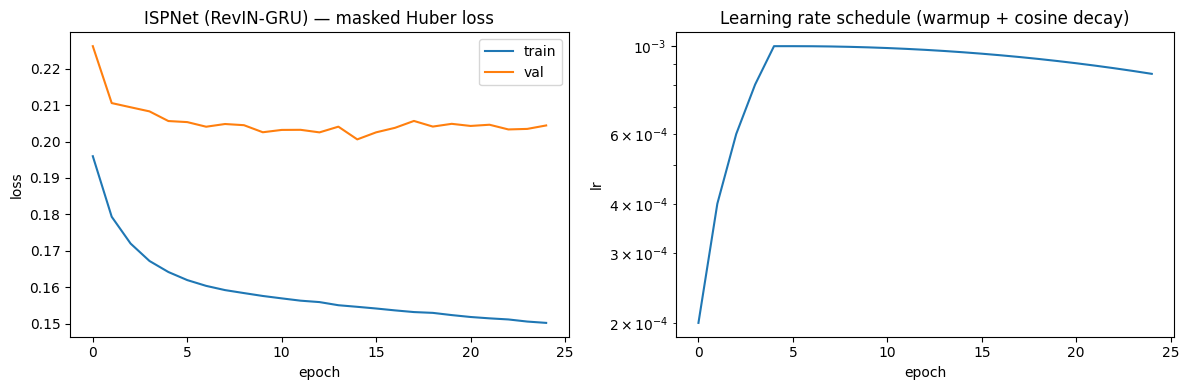

In [8]:
# ── Training loss curves ──────────────────────────────────────────────
if history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train"], label="train")
    axes[0].plot(history["val"],   label="val")
    axes[0].set_title("ISPNet (RevIN-GRU) — masked Huber loss")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
    axes[0].legend()

    axes[1].semilogy(history["lr"])
    axes[1].set_title("Learning rate schedule (warmup + cosine decay)")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("lr")

    plt.tight_layout()
    fig.savefig(RESULTS_ROOT / "ispnet_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No history to plot (loaded from checkpoint).")

In [9]:
# ── Full comparison table — 3-seed aggregates ────────────────────────
rows = []

# Baselines (single-run, no std)
if BASELINES_CSV.exists():
    df_bl = pd.read_csv(BASELINES_CSV)
    for _, r in df_bl[df_bl["level"] == "institution_subnets"].iterrows():
        rows.append({
            "model": r["model"], "group": "baseline",
            "SMAPE_median": r["SMAPE_median"], "SMAPE_median_std": 0.0,
            "SMAPE_mean": r["SMAPE_mean"],
            "R2_median": r["R2_median"], "R2_median_std": 0.0,
            "R2_clip_mean": max(r["R2_mean"], -1.0),
        })

# DL models from notebook 06 — load per-seed files (fallback: single file)
dl_models = ["lstm", "gru", "tcn", "dlinear", "transformer", "patchtst", "itransformer"]
_name_map  = {"dlinear": "DLinear", "patchtst": "PatchTST", "itransformer": "iTransformer"}
for nm in dl_models:
    seed_dfs_dl = []
    for s in SEEDS:
        p = DL_RESULTS_ROOT / f"{nm}_seed{s}_institutions_per_entity.csv"
        if p.exists():
            seed_dfs_dl.append(pd.read_csv(p))
    if not seed_dfs_dl:
        p_old = DL_RESULTS_ROOT / f"{nm}_institutions_per_entity.csv"
        if p_old.exists():
            seed_dfs_dl = [pd.read_csv(p_old)]
    if not seed_dfs_dl:
        continue
    smapes = [df["test_SMAPE"].median() for df in seed_dfs_dl]
    r2s    = [df["test_R2"].median()    for df in seed_dfs_dl]
    r2c    = [(df["test_R2_clip"].mean() if "test_R2_clip" in df.columns
               else df["test_R2"].clip(lower=-1.0).mean()) for df in seed_dfs_dl]
    disp   = nm.upper() if nm not in _name_map else _name_map[nm]
    rows.append({
        "model": disp, "group": "DL-baseline",
        "SMAPE_median": np.mean(smapes), "SMAPE_median_std": np.std(smapes),
        "SMAPE_mean":   np.mean([df["test_SMAPE"].mean() for df in seed_dfs_dl]),
        "R2_median":    np.mean(r2s),    "R2_median_std":   np.std(r2s),
        "R2_clip_mean": np.mean(r2c),
    })

# ISPNet — aggregate across seeds
isp_smapes = [df["test_SMAPE"].median() for df in all_seed_dfs_ispnet]
isp_r2s    = [df["test_R2"].median()    for df in all_seed_dfs_ispnet]
isp_r2c    = [df["test_R2_clip"].mean() for df in all_seed_dfs_ispnet]
rows.append({
    "model": "ISPNet (proposed)", "group": "proposed",
    "SMAPE_median": np.mean(isp_smapes), "SMAPE_median_std": np.std(isp_smapes),
    "SMAPE_mean":   np.mean([df["test_SMAPE"].mean() for df in all_seed_dfs_ispnet]),
    "R2_median":    np.mean(isp_r2s),    "R2_median_std":   np.std(isp_r2s),
    "R2_clip_mean": np.mean(isp_r2c),
})

cmp = pd.DataFrame(rows)
base_order = ["Mean", "SN-24", "SN-168", "MA-24", "MA-168"]
dl_order   = ["LSTM", "GRU", "TCN", "DLinear", "Transformer", "PatchTST", "iTransformer"]
prop_order = ["ISPNet (proposed)"]
order      = [m for m in base_order + dl_order + prop_order if m in cmp["model"].values]
cmp_ord    = cmp.set_index("model").reindex(order)

print(f"=== Institutions — test period (SMAPE ↓   R² ↑) ===")
print(f"Seeds: {SEEDS}  ({len(SEEDS)}-seed average ± std)\n")
display(cmp_ord[["SMAPE_median", "SMAPE_median_std", "SMAPE_mean",
                 "R2_median", "R2_median_std", "R2_clip_mean"]].round(4))

# Paper-format: mean ± std
print("\n=== Paper-format (mean ± std) ===")
paper = pd.DataFrame({
    "SMAPE_median":  cmp_ord.apply(lambda r: f"{r['SMAPE_median']:.2f} ± {r['SMAPE_median_std']:.2f}", axis=1),
    "R2_median":     cmp_ord.apply(lambda r: f"{r['R2_median']:.4f} ± {r['R2_median_std']:.4f}", axis=1),
    "R2_clip_mean":  cmp_ord["R2_clip_mean"].round(4),
})
display(paper)

# ISPNet improvement over best DL baseline
dl_cmp = cmp[cmp["group"] == "DL-baseline"]
best_dl_smape = dl_cmp["SMAPE_median"].min()
ispnet_smape  = np.mean(isp_smapes)
delta = best_dl_smape - ispnet_smape
print(f"\nISPNet vs best DL baseline: {ispnet_smape:.4f} ± {np.std(isp_smapes):.4f} "
      f"vs {best_dl_smape:.4f}  (Δ = {delta:+.4f} SMAPE pp)")

=== Institutions — test period (SMAPE ↓   R² ↑) ===
Seeds: [42, 123, 2024]  (3-seed average ± std)



,SMAPE_median,SMAPE_median_std,SMAPE_mean,R2_median,R2_median_std,R2_clip_mean
model,,,,,,
ISPNet (proposed),58.8068,0.2088,60.1529,0.1146,0.0023,0.1787



=== Paper-format (mean ± std) ===


,SMAPE_median,R2_median,R2_clip_mean
model,,,
ISPNet (proposed),58.81 ± 0.21,0.1146 ± 0.0023,0.1787



ISPNet vs best DL baseline: 58.8068 ± 0.2088 vs nan  (Δ = +nan SMAPE pp)
